# Proyecto: Telco Customer Churn Prediction
# Autor: Danilo

In [ ]:
%pip install xgboost

### Importar Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

## 📑 Diccionario de variables

El dataset contiene información de clientes de una empresa de telecomunicaciones. A continuación, se describen las principales variables:

| Variable          | Tipo       | Descripción |
|-------------------|-----------|-------------|
| **customerID**    | Categórica | Identificador único del cliente. |
| **gender**        | Categórica (Male/Female) | Género del cliente. |
| **SeniorCitizen** | Numérica (0/1) | Indica si el cliente es adulto mayor (1) o no (0). |
| **Partner**       | Categórica (Yes/No) | Si el cliente tiene pareja. |
| **Dependents**    | Categórica (Yes/No) | Si el cliente tiene personas dependientes. |
| **tenure**        | Numérica | Meses que el cliente ha permanecido con la compañía. |
| **PhoneService**  | Categórica (Yes/No) | Si el cliente tiene servicio de teléfono. |
| **MultipleLines** | Categórica (Yes/No/No phone service) | Si el cliente tiene múltiples líneas telefónicas. |
| **InternetService** | Categórica (DSL/Fiber optic/No) | Tipo de servicio de internet contratado. |
| **OnlineSecurity** | Categórica (Yes/No/No internet service) | Si tiene seguridad en línea. |
| **OnlineBackup**   | Categórica (Yes/No/No internet service) | Si tiene servicio de respaldo en línea. |
| **DeviceProtection** | Categórica (Yes/No/No internet service) | Si tiene protección de dispositivos. |
| **TechSupport**    | Categórica (Yes/No/No internet service) | Si tiene soporte técnico. |
| **StreamingTV**    | Categórica (Yes/No/No internet service) | Si tiene servicio de streaming de TV. |
| **StreamingMovies** | Categórica (Yes/No/No internet service) | Si tiene servicio de streaming de películas. |
| **Contract**       | Categórica (Month-to-month/One year/Two year) | Tipo de contrato del cliente. |
| **PaperlessBilling** | Categórica (Yes/No) | Si el cliente recibe facturación electrónica. |
| **PaymentMethod**   | Categórica | Método de pago (Ej: Electronic check, Credit card, Bank transfer, Mailed check). |
| **MonthlyCharges**  | Numérica | Monto de la factura mensual del cliente. |
| **TotalCharges**    | Numérica | Total facturado al cliente durante su permanencia. |
| **Churn**           | Categórica (Yes/No) | **Variable objetivo**: indica si el cliente abandonó (Yes) o no (No) el servicio. |



### Cargar Dataset

In [27]:
df = pd.read_csv('C:\\Users\\Danilo\\Documents\\Proyectos Full\\IA\\AI-Portfolio-DaniloRivera\\Proyecto07_Predicción_análisis_abandono_clientes_empresa_telecomunicaciones\\data\\Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:

print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (7043, 21)


## Análisis exploratorio (EDA)

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print("Cantidad de nulos por columna:\n", df.isnull().sum())

Cantidad de nulos por columna:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64



Distribución de la variable objetivo (Churn):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


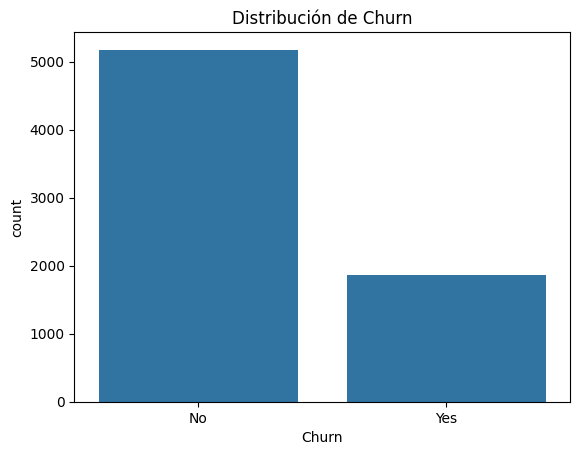

In [6]:
print("\nDistribución de la variable objetivo (Churn):")
print(df['Churn'].value_counts(normalize=True) * 100)
sns.countplot(x="Churn", data=df)
plt.title("Distribución de Churn")
plt.show()

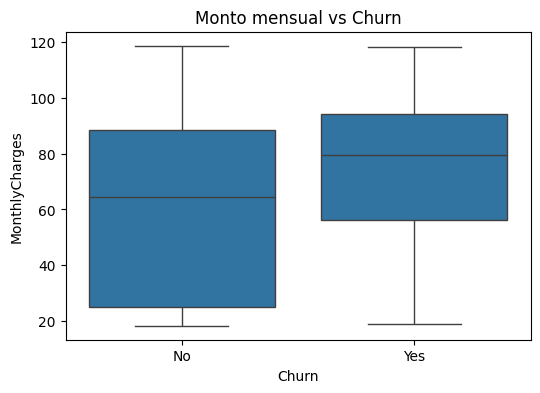

In [7]:
# Ejemplo: monto mensual vs churn
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monto mensual vs Churn")
plt.show()

## Preparación de datos

In [28]:
# Eliminar columnas irrelevantes
df = df.drop(["customerID"], axis=1)

# Convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [29]:
# Codificación de variables categóricas
for col in df.select_dtypes(include=["object"]).columns:
    if col != "Churn":
        df[col] = LabelEncoder().fit_transform(df[col])

In [10]:
# Variable objetivo
y = df["Churn"].map({"Yes":1, "No":0})
X = df.drop("Churn", axis=1)

In [11]:
# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


## Modelos ML

In [13]:

# Modelo 1: Regresión Logística
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print("\n--- Regresión Logística ---")
print(classification_report(y_test, y_pred_log))


--- Regresión Logística ---
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1539
           1       0.68      0.57      0.62       574

    accuracy                           0.81      2113
   macro avg       0.76      0.74      0.75      2113
weighted avg       0.80      0.81      0.81      2113



In [14]:
# Modelo 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1539
           1       0.68      0.49      0.57       574

    accuracy                           0.80      2113
   macro avg       0.75      0.70      0.72      2113
weighted avg       0.79      0.80      0.79      2113



In [16]:
# Modelo 3: XGBoost
xgb_model = xgb.XGBClassifier(eval_metric="logloss")
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("\n--- XGBoost ---")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_xgb))


--- XGBoost ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1539
           1       0.64      0.52      0.58       574

    accuracy                           0.79      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.78      0.79      0.78      2113

ROC AUC Score: 0.7067431451256869


## Feature Importance (Random Forest)

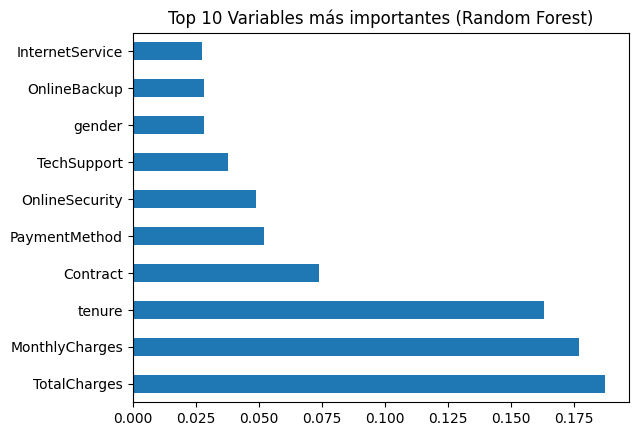

In [17]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind="barh")
plt.title("Top 10 Variables más importantes (Random Forest)")
plt.show()

## Validacion de los Modelos

In [18]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Validación K-Fold estratificada
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Definir métricas
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score)
}

# Modelos a evaluar
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric="logloss")
}

# Lista para guardar resultados
results_list = []

# Evaluación K-Fold
for name, model in models.items():
    cv_results = cross_validate(model, X_scaled, y, cv=kfold, scoring=scoring)
    
    results_list.append({
        'Model': name,
        'Accuracy': f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
        'Precision': f"{cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}",
        'Recall': f"{cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}",
        'F1': f"{cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}",
        'ROC_AUC': f"{cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}"
    })

# Convertir lista a DataFrame
results_df = pd.DataFrame(results_list)

# Mostrar tabla comparativa
print(results_df)

                 Model         Accuracy        Precision           Recall  \
0  Logistic Regression  0.8033 ± 0.0179  0.6534 ± 0.0381  0.5511 ± 0.0464   
1        Random Forest  0.7954 ± 0.0124  0.6503 ± 0.0355  0.5008 ± 0.0349   
2              XGBoost  0.7856 ± 0.0146  0.6152 ± 0.0353  0.5185 ± 0.0277   

                F1          ROC_AUC  
0  0.5974 ± 0.0410  0.7228 ± 0.0261  
1  0.5647 ± 0.0261  0.7013 ± 0.0162  
2  0.5621 ± 0.0257  0.7003 ± 0.0163  


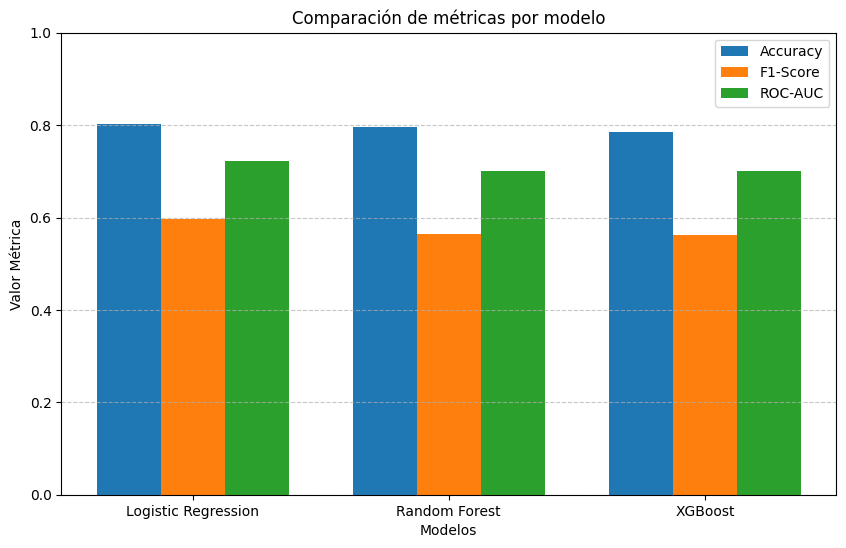

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar los datos
models_names = results_df['Model']
accuracy = [float(x.split(' ± ')[0]) for x in results_df['Accuracy']]
f1 = [float(x.split(' ± ')[0]) for x in results_df['F1']]
roc_auc = [float(x.split(' ± ')[0]) for x in results_df['ROC_AUC']]

x = np.arange(len(models_names))  # la posición de los grupos
width = 0.25  # ancho de las barras

# Crear gráfico
fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - width, accuracy, width, label='Accuracy', color='#1f77b4')
ax.bar(x, f1, width, label='F1-Score', color='#ff7f0e')
ax.bar(x + width, roc_auc, width, label='ROC-AUC', color='#2ca02c')

# Etiquetas y título
ax.set_xlabel('Modelos')
ax.set_ylabel('Valor Métrica')
ax.set_title('Comparación de métricas por modelo')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar gráfico
plt.show()


In [ ]:
%pip install nbformat


In [20]:
import plotly.graph_objects as go

# Preparar los datos
models_names = results_df['Model']
accuracy = [float(x.split(' ± ')[0]) for x in results_df['Accuracy']]
f1 = [float(x.split(' ± ')[0]) for x in results_df['F1']]
roc_auc = [float(x.split(' ± ')[0]) for x in results_df['ROC_AUC']]

# Crear figura
fig = go.Figure(data=[
    go.Bar(name='Accuracy', x=models_names, y=accuracy, text=[f"{v:.2f}" for v in accuracy], textposition='auto'),
    go.Bar(name='F1-Score', x=models_names, y=f1, text=[f"{v:.2f}" for v in f1], textposition='auto'),
    go.Bar(name='ROC-AUC', x=models_names, y=roc_auc, text=[f"{v:.2f}" for v in roc_auc], textposition='auto')
])

# Configurar layout
fig.update_layout(
    title='Comparación de métricas por modelo',
    xaxis_title='Modelos',
    yaxis_title='Valor Métrica',
    yaxis=dict(range=[0,1]),
    barmode='group',  # Barras agrupadas
    template='plotly_white'
)

# Mostrar gráfico interactivo
fig.show()


## 📊 Conclusiones del Análisis de Modelos

A partir de la validación K-Fold de los modelos de predicción de churn, se obtuvieron los siguientes resultados:

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|----|---------|
| Logistic Regression | 0.803 | 0.653 | 0.551 | 0.597 | 0.723 |
| Random Forest | 0.795 | 0.650 | 0.501 | 0.565 | 0.701 |
| XGBoost | 0.786 | 0.615 | 0.519 | 0.562 | 0.700 |

### Principales conclusiones

1. **Modelo más consistente:**  
   - La **Regresión Logística** muestra el mejor equilibrio entre Accuracy, F1 y ROC-AUC, siendo eficaz para capturar los patrones principales del dataset.

2. **Interpretabilidad vs Complejidad:**  
   - Logistic Regression es **fácil de interpretar** y permite identificar qué variables influyen más en el churn.  
   - Random Forest y XGBoost son modelos más complejos y requieren **tuning** para superar a la regresión logística.

3. **Métricas de clase positiva:**  
   - Las métricas de Precision (~0.65) y Recall (~0.55) indican que hay falsos positivos y falsos negativos, sugiriendo que el modelo podría mejorar con **feature engineering** o más datos.

4. **ROC-AUC:**  
   - La regresión logística alcanza 0.723, mostrando un buen poder de discriminación entre clientes que abandonan y los que no.

5. **Recomendaciones para mejora:**  
   - Ajustar hiperparámetros en Random Forest y XGBoost.  
   - Crear nuevas variables derivadas para mejorar la predicción.  
   - Considerar técnicas de balanceo de clases si el dataset está desbalanceado.  
   - Explorar modelos ensemble o redes neuronales para obtener mejoras marginales.

**Conclusión final:**  

> La **Regresión Logística** es el modelo más eficiente y estable para este dataset, ofreciendo un buen desempeño con interpretabilidad clara, mientras que los modelos complejos requieren ajustes adicionales para superar su rendimiento.


In [ ]:

# Guardar el DataFrame de resultados en un archivo CSV
results_df.to_csv('model_comparison_results.csv', index=False)